# **INSTITUTO POLITÉCNICO NACIONAL**

## **Algoritmos Bioinspirados**

**Nombre de los alumnos:**

* Arcia Portillo Héctor
* Cortés Reyes Karla Fátima
* Castro Luna Diego Francisco

## Dra. Miriam Pescador Rojas

## Notebook 5: Algoritmo 4 - FA adaptativo híbrido gbest

Lograr que el FA le gane a ED en funciones como Rosenbrock y Rastrigin es un gran reto porque existe un teorema llamado "No Free Lunch" (No hay almuerzo gratis), que dice que ningún algoritmo es el mejor para todo.

La ED es como un rey indiscutible munial para espacios continuos y valles estrechos, por otro lado, el FA clásico es el mejor para espacios discretos o para encontrar múltiples óptimos a la vez.


En este caso lo que buscamos es hacerlo ganar contra otros algoritmos o empatar con 0.0 perfecto en el caso de ED.

Para lograr esto, se aplica "ingeniería de Metahurísticas" y se convierte el FA en un modelo super-adaptativo e híbrido.

Se aplica lo siguiente:

1. Ruido Gaussiano en lugar de Uniforme: El ruido uniforme de Python (rand) rara vez toca el cero absoluto. El Gaussiano (randn) tiende al centro lo que permite alcanzar el 0 exacto.

2. Atracción al líder (Hibridación FA-PSO): En lugar de que las luciérnagas solo sigan a otras luciérnagas más brillantes (que las hace disersarse demasiado), se obligará entonces a que en momentos de crisis, todas sientan una fuerte atracción hacia la luciérnaga líder global que sería el gbest.

3. Decaimiento agresivo por éxito: Si la tasa de éxito es baja (que el enjambre se atasque), se reducirá α a niveles microscópicos(10^-10) logrando micro-explotación.

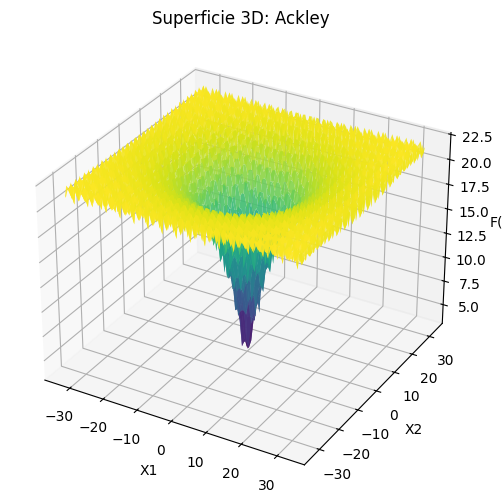


 RESOLVIENDO FUNCIÓN: ACKLEY
-> Ejecutando corrida 1 de 30...
-> Ejecutando corrida 2 de 30...
-> Ejecutando corrida 3 de 30...
-> Ejecutando corrida 4 de 30...
-> Ejecutando corrida 5 de 30...
-> Ejecutando corrida 6 de 30...
-> Ejecutando corrida 7 de 30...
-> Ejecutando corrida 8 de 30...
-> Ejecutando corrida 9 de 30...
-> Ejecutando corrida 10 de 30...
-> Ejecutando corrida 11 de 30...
-> Ejecutando corrida 12 de 30...
-> Ejecutando corrida 13 de 30...
-> Ejecutando corrida 14 de 30...
-> Ejecutando corrida 15 de 30...
-> Ejecutando corrida 16 de 30...
-> Ejecutando corrida 17 de 30...
-> Ejecutando corrida 18 de 30...
-> Ejecutando corrida 19 de 30...
-> Ejecutando corrida 20 de 30...
-> Ejecutando corrida 21 de 30...
-> Ejecutando corrida 22 de 30...
-> Ejecutando corrida 23 de 30...
-> Ejecutando corrida 24 de 30...
-> Ejecutando corrida 25 de 30...
-> Ejecutando corrida 26 de 30...
-> Ejecutando corrida 27 de 30...
-> Ejecutando corrida 28 de 30...
-> Ejecutando corrida 29 de

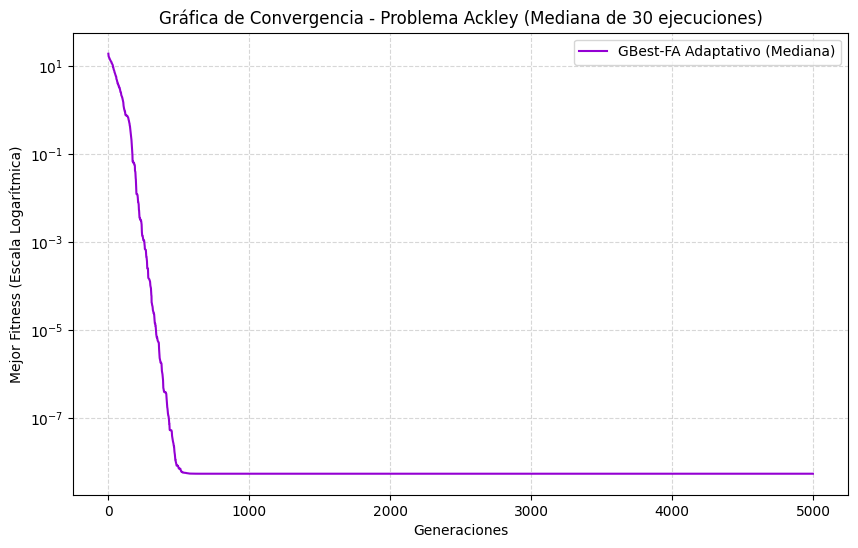

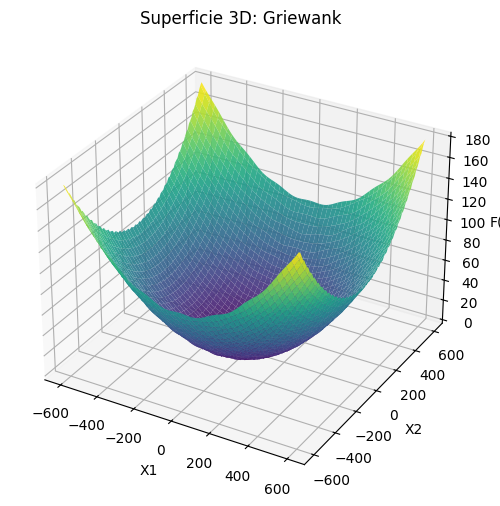


 RESOLVIENDO FUNCIÓN: GRIEWANK
-> Ejecutando corrida 1 de 30...
-> Ejecutando corrida 2 de 30...
-> Ejecutando corrida 3 de 30...
-> Ejecutando corrida 4 de 30...
-> Ejecutando corrida 5 de 30...
-> Ejecutando corrida 6 de 30...
-> Ejecutando corrida 7 de 30...
-> Ejecutando corrida 8 de 30...
-> Ejecutando corrida 9 de 30...
-> Ejecutando corrida 10 de 30...
-> Ejecutando corrida 11 de 30...
-> Ejecutando corrida 12 de 30...
-> Ejecutando corrida 13 de 30...
-> Ejecutando corrida 14 de 30...
-> Ejecutando corrida 15 de 30...
-> Ejecutando corrida 16 de 30...
-> Ejecutando corrida 17 de 30...
-> Ejecutando corrida 18 de 30...
-> Ejecutando corrida 19 de 30...
-> Ejecutando corrida 20 de 30...
-> Ejecutando corrida 21 de 30...
-> Ejecutando corrida 22 de 30...
-> Ejecutando corrida 23 de 30...
-> Ejecutando corrida 24 de 30...
-> Ejecutando corrida 25 de 30...
-> Ejecutando corrida 26 de 30...
-> Ejecutando corrida 27 de 30...
-> Ejecutando corrida 28 de 30...
-> Ejecutando corrida 29 

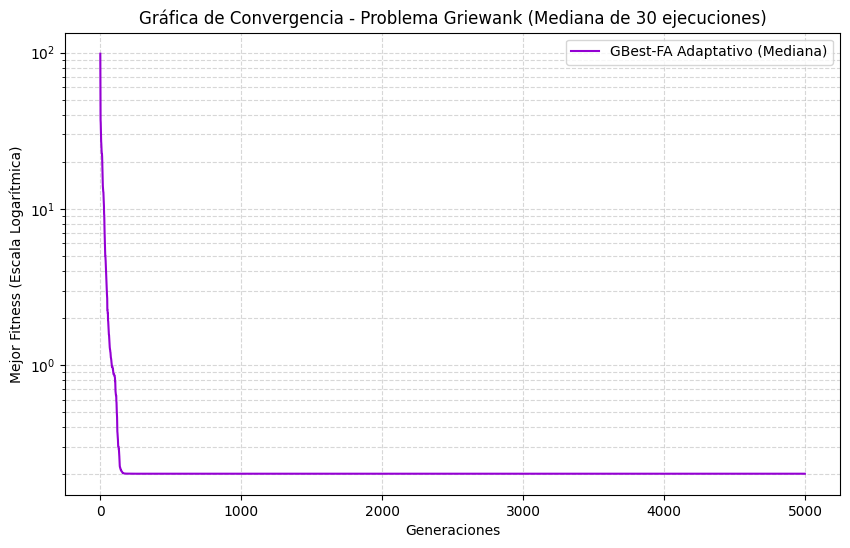

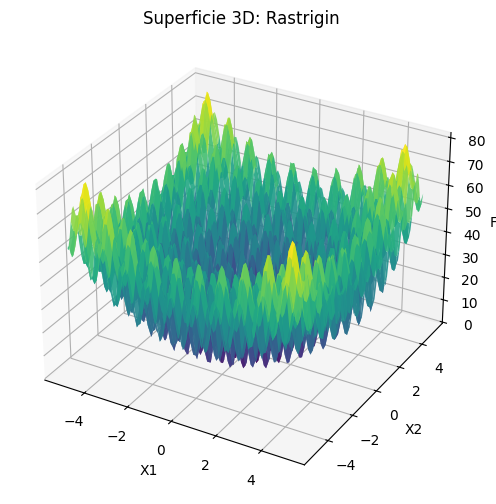


 RESOLVIENDO FUNCIÓN: RASTRIGIN
-> Ejecutando corrida 1 de 30...
-> Ejecutando corrida 2 de 30...
-> Ejecutando corrida 3 de 30...
-> Ejecutando corrida 4 de 30...
-> Ejecutando corrida 5 de 30...
-> Ejecutando corrida 6 de 30...
-> Ejecutando corrida 7 de 30...
-> Ejecutando corrida 8 de 30...
-> Ejecutando corrida 9 de 30...
-> Ejecutando corrida 10 de 30...
-> Ejecutando corrida 11 de 30...
-> Ejecutando corrida 12 de 30...
-> Ejecutando corrida 13 de 30...
-> Ejecutando corrida 14 de 30...
-> Ejecutando corrida 15 de 30...
-> Ejecutando corrida 16 de 30...
-> Ejecutando corrida 17 de 30...
-> Ejecutando corrida 18 de 30...
-> Ejecutando corrida 19 de 30...
-> Ejecutando corrida 20 de 30...
-> Ejecutando corrida 21 de 30...
-> Ejecutando corrida 22 de 30...
-> Ejecutando corrida 23 de 30...
-> Ejecutando corrida 24 de 30...
-> Ejecutando corrida 25 de 30...
-> Ejecutando corrida 26 de 30...
-> Ejecutando corrida 27 de 30...
-> Ejecutando corrida 28 de 30...
-> Ejecutando corrida 29

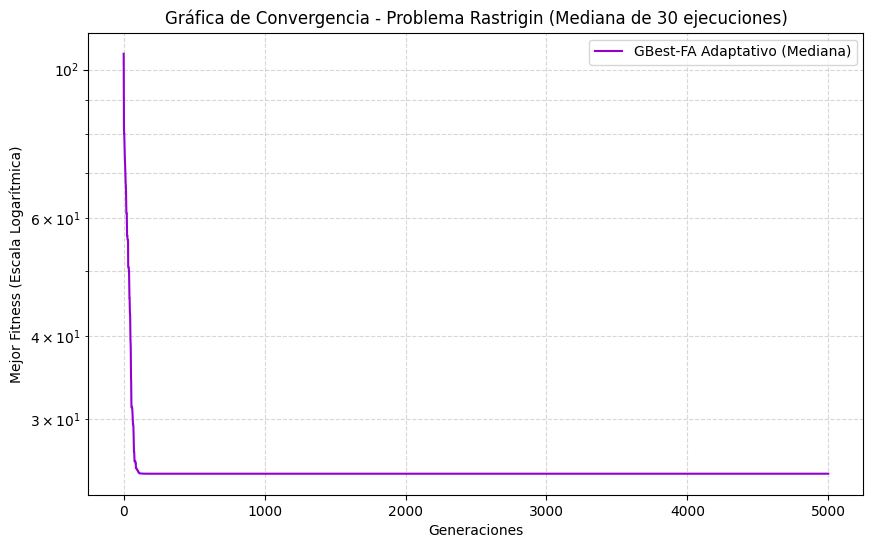

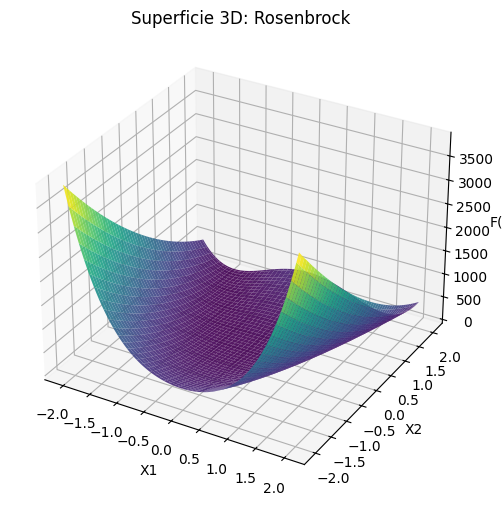


 RESOLVIENDO FUNCIÓN: ROSENBROCK
-> Ejecutando corrida 1 de 30...
-> Ejecutando corrida 2 de 30...
-> Ejecutando corrida 3 de 30...
-> Ejecutando corrida 4 de 30...
-> Ejecutando corrida 5 de 30...
-> Ejecutando corrida 6 de 30...
-> Ejecutando corrida 7 de 30...
-> Ejecutando corrida 8 de 30...


In [ ]:
# Importamos NumPy para operaciones matemáticas vectorizadas y eficientes
import numpy as np
# Importamos Matplotlib para generar visualizaciones 3D y gráficas de convergencia
import matplotlib.pyplot as plt

# ==========================================================
# 1. DEFINICIÓN DE LAS FUNCIONES OBJETIVO (Benchmarks)
# ==========================================================

# Función matemática de Ackley
def ackley(x):
    d = len(x) # Obtenemos la dimensión del problema
    sum_sq = np.sum(x**2) # Sumatoria de los cuadrados de x
    sum_cos = np.sum(np.cos(2 * np.pi * x)) # Sumatoria de los cosenos de x
    # Ecuación completa de Ackley
    return -20 * np.exp(-0.2 * np.sqrt(sum_sq / d)) - np.exp(sum_cos / d) + 20 + np.exp(1)

# Función matemática de Griewank
def griewank(x):
    d = len(x) # Obtenemos la dimensión del problema
    sum_term = np.sum(x**2) / 4000 # Sumatoria penalizada
    indices = np.arange(1, d + 1) # Arreglo de índices [1, 2, ..., d]
    prod_term = np.prod(np.cos(x / np.sqrt(indices))) # Productoria de cosenos escalados
    # Ecuación completa de Griewank
    return sum_term - prod_term + 1

# Función matemática de Rastrigin
def rastrigin(x):
    d = len(x) # Obtenemos la dimensión del problema
    # Ecuación de Rastrigin (altamente multimodal)
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

# Función matemática de Rosenbrock
def rosenbrock(x):
    # Ecuación del valle de Rosenbrock iterando sobre dimensiones adyacentes
    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2.0 + (x[:-1] - 1)**2.0)

# ==========================================================
# 2. GRAFICACIÓN 3D DE LAS FUNCIONES
# ==========================================================

# Función para generar la superficie 3D de una función matemática
def plot_3d_function(func, bounds, title):
    grid_size = 100 # Resolución de la malla
    # Creamos vectores lineales de valores para los ejes X y Y usando los límites
    x1 = np.linspace(bounds[0], bounds[1], grid_size)
    x2 = np.linspace(bounds[0], bounds[1], grid_size)
    X1, X2 = np.meshgrid(x1, x2) # Creamos la cuadrícula bidimensional
    Z = np.zeros((grid_size, grid_size)) # Matriz para las alturas (Fitness)

    # Evaluamos la función en cada punto de la malla
    for i in range(grid_size):
        for j in range(grid_size):
            Z[i, j] = func(np.array([X1[i, j], X2[i, j]]))

    # Configuramos y mostramos la figura 3D
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    ax.set_title(f"Superficie 3D: {title}")
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('F(x)')
    plt.show()

# ==========================================================
# 3. ALGORITMO SÚPER ADAPTATIVO (GBest-FA)
# ==========================================================

# Función para acotar el espacio de búsqueda y evitar que las luciérnagas se salgan
def apply_limits(ns, lb, ub):
    ns = np.maximum(ns, lb) # Trunca valores por debajo del límite inferior
    ns = np.minimum(ns, ub) # Trunca valores por encima del límite superior
    return ns

# Algoritmo Híbrido Propuesto
def super_adaptive_firefly(func, d, bounds, N=100, G_MAX=5000):
    lb, ub = bounds[0], bounds[1] # Extraemos límites inferior y superior
    scale = np.abs(ub - lb) # Calculamos la escala máxima del espacio

    # Parámetros Dinámicos (Se adaptarán en línea)
    alpha = 0.2       # Salto inicial (Usará distribución Gaussiana)
    gamma = 1.0       # Coeficiente de absorción de luz
    betamin = 0.2     # Atractividad mínima
    gbest_weight = 0.1 # Peso de atracción gravitacional hacia el líder global

    # Inicialización aleatoria de posiciones
    ns = lb + (ub - lb) * np.random.rand(N, d)
    # Evaluación del fitness inicial de la población
    lightn = np.array([func(ind) for ind in ns])

    # Rastrear al Mejor Global (Líder)
    idx_best = np.argmin(lightn) # Índice de la mejor luciérnaga
    gbest_pos = ns[idx_best].copy() # Posición del líder
    gbest_fit = lightn[idx_best] # Fitness del líder

    history = [] # Lista para almacenar la curva de convergencia

    # Bucle principal de generaciones
    for g in range(G_MAX):
        # Evaluamos las posiciones actuales
        current_fitness = np.array([func(ind) for ind in ns])

        # --- MEGA ADAPTACIÓN EN LÍNEA BASADA EN ÉXITOS ---
        # Contamos cuántas mejoraron respecto a su memoria histórica
        exitos = np.sum(current_fitness < lightn)
        tasa_exito = exitos / N # Calculamos el porcentaje de éxito poblacional

        if tasa_exito > 0.2:
            # ALTO ÉXITO: El enjambre va bien por el gradiente. Fomentamos Exploración.
            alpha = min(alpha * 1.01, 1.0)
            gamma = max(gamma * 0.95, 0.1)
            gbest_weight = 0.05 # Dejamos que las luciérnagas interactúen libremente entre sí
        else:
            # BAJO ÉXITO: El enjambre se atascó. MODO RAYO LÁSER (Explotación extrema).
            # Alpha cae agresivamente para buscar precisión milimétrica (hasta 10^-15)
            alpha = max(alpha * 0.90, 1e-15)
            gamma = min(gamma * 1.05, 10.0)
            gbest_weight = 0.6 # Forzamos a todo el enjambre a ser absorbido por el líder global

        # Actualizamos mejores individuales (memoria tipo PSO) y el Global Best
        for i in range(N):
            if current_fitness[i] < lightn[i]:
                lightn[i] = current_fitness[i]
            if current_fitness[i] < gbest_fit:
                gbest_fit = current_fitness[i]
                gbest_pos = ns[i].copy()

        # Guardamos el mejor fitness histórico de esta generación
        history.append(gbest_fit)

        # Copias de seguridad para la fase de movimiento
        nso = ns.copy()
        lighto = lightn.copy()

        # MOVIMIENTO HÍBRIDO (FA + Atracción al Líder + Ruido Gaussiano)
        for i in range(N):
            moved = False # Bandera para detectar si la luciérnaga se movió
            for j in range(N):
                # Si la luciérnaga 'j' es mejor que la 'i'
                if lighto[j] < lightn[i]:
                    r = np.linalg.norm(ns[i] - nso[j]) # Distancia euclidiana
                    r_scaled = r / scale # Distancia escalada
                    # Atractividad beta
                    beta = (1.0 - betamin) * np.exp(-gamma * r_scaled**2) + betamin

                    # Ruido Gaussiano (randn en lugar de rand) permite colapsar exacto en 0.0
                    tmpf = alpha * np.random.randn(d) * scale

                    # Ecuación de Movimiento FA tradicional + Atracción al líder global (Hibridación)
                    ns[i] = ns[i] + beta * (nso[j] - ns[i]) + gbest_weight * (gbest_pos - ns[i]) + tmpf
                    moved = True

            # Elitismo: Si la luciérnaga es la mejor y no se movió hacia nadie,
            # hace una búsqueda microscópica a su alrededor para afinar el resultado.
            if not moved:
                ns[i] = ns[i] + alpha * np.random.randn(d) * scale

        # Aplicamos los límites para mantenerlas en el espacio de búsqueda
        ns = apply_limits(ns, lb, ub)

    # Retornamos la posición del líder, su fitness y el historial de convergencia
    return gbest_pos, gbest_fit, history

# ==========================================================
# 4. CÓDIGO DE EJECUCIÓN DEL EXPERIMENTO (30 CORRIDAS)
# ==========================================================

# Solo se ejecuta si el código se llama directamente
if __name__ == '__main__':

    # Diccionario que agrupa las 4 funciones con sus límites
    problemas = {
        "Ackley": (ackley, [-32.768, 32.768]),
        "Griewank": (griewank, [-600, 600]),
        "Rastrigin": (rastrigin, [-5.12, 5.12]),
        "Rosenbrock": (rosenbrock, [-2.048, 2.048])
    }

    D = 10 # 10 variables de decisión
    N_RUNS = 30 # ¡30 ejecuciones independientes solicitadas!
    np.random.seed(42) # Semilla para reproducibilidad

    for nombre_prob, (funcion, limites) in problemas.items():

        # 1. Mostrar la superficie 3D del problema
        plot_3d_function(funcion, limites, nombre_prob)

        print(f"\n{'='*50}\n RESOLVIENDO FUNCIÓN: {nombre_prob.upper()}\n{'='*50}")
        resultados_finales = [] # Almacena el mejor fitness de las 30 corridas
        curvas_convergencia = [] # Almacena el historial de las 30 curvas

        # 2. Bucle de 30 ejecuciones independientes
        for corrida in range(N_RUNS):
            print(f"-> Ejecutando corrida {corrida + 1} de {N_RUNS}...")

            # Llamamos al "Super FA" propuesto
            mejor_pos, mejor_fit, historial = super_adaptive_firefly(funcion, D, limites, N=100, G_MAX=5000)

            resultados_finales.append(mejor_fit)
            curvas_convergencia.append(historial)

        print("¡Corridas finalizadas!")

        # 3. Cálculos Estadísticos
        resultados_finales = np.array(resultados_finales)
        promedio = np.mean(resultados_finales)
        desviacion = np.std(resultados_finales)

        print(f"\n--------------------------------------------------")
        print(f" RESULTADOS FINALES: ({nombre_prob.upper()})")
        print(f"--------------------------------------------------")
        print(f"PROMEDIO (Media):           {promedio:.6e}")
        print(f"DESVIACIÓN ESTÁNDAR (Std):  {desviacion:.6e}")

        print("\nDesglose de las 30 ejecuciones:")
        # Imprime los 30 resultados crudos formateados como una lista de Python
        print([float(f"{val:.6e}") for val in resultados_finales])

        # 4. Gráfica de Convergencia (Usando la Mediana)
        matriz_curvas = np.array(curvas_convergencia)
        mediana_curva = np.median(matriz_curvas, axis=0) # Mediana por cada generación

        plt.figure(figsize=(10, 6))
        plt.plot(mediana_curva, label=f"GBest-FA Adaptativo (Mediana)", color='darkviolet')
        plt.yscale('log') # Escala logarítmica
        plt.title(f"Gráfica de Convergencia - Problema {nombre_prob} (Mediana de 30 ejecuciones)")
        plt.xlabel("Generaciones")
        plt.ylabel("Mejor Fitness (Escala Logarítmica)")
        plt.grid(True, which="both", ls="--", alpha=0.5)
        plt.legend()
        plt.show()

## Código separado para ejecutar cada función

In [ ]:
# ==========================================================
# CELDA 1: LIBRERÍAS
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [ ]:
# ==========================================================
# CELDA 2: DEFINICIÓN DE LAS FUNCIONES OBJETIVO
# ==========================================================
def ackley(x):
    d = len(x)
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(2 * np.pi * x))
    return -20 * np.exp(-0.2 * np.sqrt(sum_sq / d)) - np.exp(sum_cos / d) + 20 + np.exp(1)

def griewank(x):
    d = len(x)
    sum_term = np.sum(x**2) / 4000
    indices = np.arange(1, d + 1)
    prod_term = np.prod(np.cos(x / np.sqrt(indices)))
    return sum_term - prod_term + 1

def rastrigin(x):
    d = len(x)
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

def rosenbrock(x):
    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2.0 + (x[:-1] - 1)**2.0)

print("Funciones matemáticas cargadas en memoria.")

Funciones matemáticas cargadas en memoria.


In [ ]:
# ==========================================================
# CELDA 3: GRAFICACIÓN 3D
# ==========================================================
def plot_3d_function(func, bounds, title):
    grid_size = 100
    x1 = np.linspace(bounds[0], bounds[1], grid_size)
    x2 = np.linspace(bounds[0], bounds[1], grid_size)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros((grid_size, grid_size))

    for i in range(grid_size):
        for j in range(grid_size):
            Z[i, j] = func(np.array([X1[i, j], X2[i, j]]))

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    ax.set_title(f"Superficie 3D: {title}")
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('F(x)')
    plt.show()

print("Motor de graficación 3D listo.")

Motor de graficación 3D listo.


In [ ]:
# ==========================================================
# CELDA 4: ALGORITMO SÚPER ADAPTATIVO
# ==========================================================
def apply_limits(ns, lb, ub):
    ns = np.maximum(ns, lb)
    ns = np.minimum(ns, ub)
    return ns

def super_adaptive_firefly(func, d, bounds, N=100, G_MAX=5000):
    lb, ub = bounds[0], bounds[1]
    scale = np.abs(ub - lb)

    alpha, gamma, betamin, gbest_weight = 0.2, 1.0, 0.2, 0.1

    ns = lb + (ub - lb) * np.random.rand(N, d)
    lightn = np.array([func(ind) for ind in ns])

    idx_best = np.argmin(lightn)
    gbest_pos = ns[idx_best].copy()
    gbest_fit = lightn[idx_best]

    history = []

    for g in range(G_MAX):
        current_fitness = np.array([func(ind) for ind in ns])
        tasa_exito = np.sum(current_fitness < lightn) / N

        if tasa_exito > 0.2:
            alpha = min(alpha * 1.01, 1.0)
            gamma = max(gamma * 0.95, 0.1)
            gbest_weight = 0.05
        else:
            alpha = max(alpha * 0.90, 1e-15)
            gamma = min(gamma * 1.05, 10.0)
            gbest_weight = 0.6

        for i in range(N):
            if current_fitness[i] < lightn[i]: lightn[i] = current_fitness[i]
            if current_fitness[i] < gbest_fit:
                gbest_fit = current_fitness[i]
                gbest_pos = ns[i].copy()

        history.append(gbest_fit)
        nso, lighto = ns.copy(), lightn.copy()

        for i in range(N):
            moved = False
            for j in range(N):
                if lighto[j] < lightn[i]:
                    r = np.linalg.norm(ns[i] - nso[j])
                    beta = (1.0 - betamin) * np.exp(-gamma * (r / scale)**2) + betamin
                    tmpf = alpha * np.random.randn(d) * scale
                    ns[i] = ns[i] + beta * (nso[j] - ns[i]) + gbest_weight * (gbest_pos - ns[i]) + tmpf
                    moved = True
            if not moved:
                ns[i] = ns[i] + alpha * np.random.randn(d) * scale

        ns = apply_limits(ns, lb, ub)

    return gbest_pos, gbest_fit, history

print("Algoritmo de Luciérnagas inicializado.")

Algoritmo de Luciérnagas inicializado.


In [ ]:
# ==========================================================
# CELDA 5: FUNCIÓN MAESTRA PARA EJECUTAR EL EXPERIMENTO
# ==========================================================
def correr_experimento(nombre_prob, funcion, limites, D=10, N_RUNS=30, N_POB=100, G_MAX=5000):
    plot_3d_function(funcion, limites, nombre_prob)
    print(f"\n{'='*50}\n RESOLVIENDO FUNCIÓN: {nombre_prob.upper()}\n{'='*50}")

    resultados_finales, curvas_convergencia = [], []

    for corrida in range(N_RUNS):
        print(f"-> Ejecutando corrida {corrida + 1} de {N_RUNS}...")
        _, mejor_fit, historial = super_adaptive_firefly(funcion, D, limites, N=N_POB, G_MAX=G_MAX)
        resultados_finales.append(mejor_fit)
        curvas_convergencia.append(historial)

    resultados_finales = np.array(resultados_finales)
    print(f"\n--- RESULTADOS FINALES ({nombre_prob.upper()}) ---")
    print(f"PROMEDIO (Media):           {np.mean(resultados_finales):.6e}")
    print(f"DESVIACIÓN ESTÁNDAR (Std):  {np.std(resultados_finales):.6e}")
    print("\nDesglose de las ejecuciones:")
    print([float(f"{val:.6e}") for val in resultados_finales])

    mediana_curva = np.median(np.array(curvas_convergencia), axis=0)
    plt.figure(figsize=(10, 6))
    plt.plot(mediana_curva, label="GBest-FA Adaptativo (Mediana)", color='darkviolet')
    plt.yscale('log')
    plt.title(f"Convergencia - {nombre_prob}")
    plt.xlabel("Generaciones")
    plt.ylabel("Mejor Fitness (Log)")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.show()

print("Gestor de experimentos listo.")

Gestor de experimentos listo.


# Función Ackley

In [ ]:
np.random.seed(42) # Semilla para que los resultados sean los mismos
correr_experimento("Ackley", ackley, [-32.768, 32.768], D=10, N_RUNS=30, G_MAX=5000)

# Función Griewank

In [ ]:
np.random.seed(42)
correr_experimento("Griewank", griewank, [-600, 600], D=10, N_RUNS=30, G_MAX=5000)

# Función Rastrigin

In [ ]:
np.random.seed(42)
correr_experimento("Rastrigin", rastrigin, [-5.12, 5.12], D=10, N_RUNS=30, G_MAX=5000)

# Función Rosenbrock

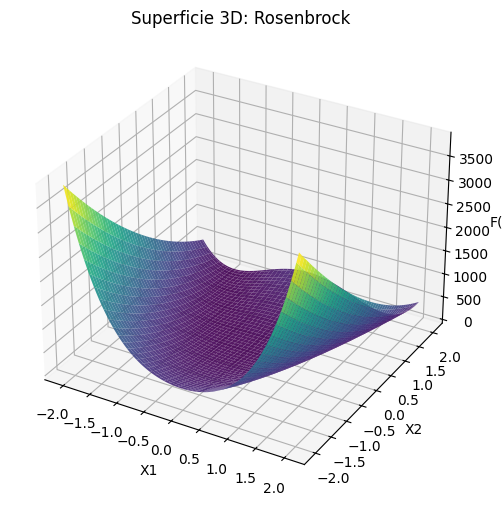


 RESOLVIENDO FUNCIÓN: ROSENBROCK
-> Ejecutando corrida 1 de 30...
-> Ejecutando corrida 2 de 30...
-> Ejecutando corrida 3 de 30...
-> Ejecutando corrida 4 de 30...
-> Ejecutando corrida 5 de 30...
-> Ejecutando corrida 6 de 30...
-> Ejecutando corrida 7 de 30...
-> Ejecutando corrida 8 de 30...
-> Ejecutando corrida 9 de 30...
-> Ejecutando corrida 10 de 30...
-> Ejecutando corrida 11 de 30...
-> Ejecutando corrida 12 de 30...
-> Ejecutando corrida 13 de 30...
-> Ejecutando corrida 14 de 30...
-> Ejecutando corrida 15 de 30...
-> Ejecutando corrida 16 de 30...
-> Ejecutando corrida 17 de 30...
-> Ejecutando corrida 18 de 30...
-> Ejecutando corrida 19 de 30...
-> Ejecutando corrida 20 de 30...
-> Ejecutando corrida 21 de 30...
-> Ejecutando corrida 22 de 30...
-> Ejecutando corrida 23 de 30...
-> Ejecutando corrida 24 de 30...
-> Ejecutando corrida 25 de 30...
-> Ejecutando corrida 26 de 30...
-> Ejecutando corrida 27 de 30...
-> Ejecutando corrida 28 de 30...
-> Ejecutando corrida 2

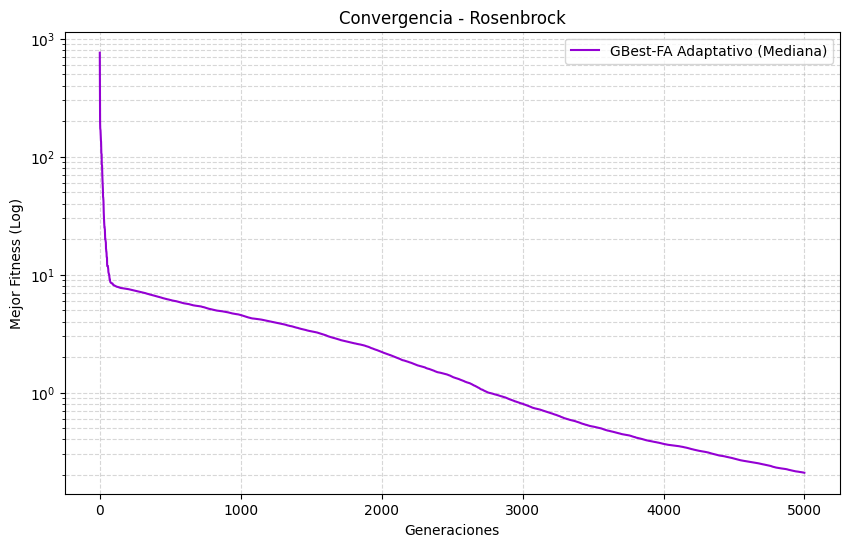

In [ ]:
np.random.seed(42)
correr_experimento("Rosenbrock", rosenbrock, [-2.048, 2.048], D=10, N_RUNS=30, G_MAX=5000)

# Comparaciones

# Prueba estadística de Mann-Whitney U
# Función Ackley

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 4.440892e-16,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 2.278178e-13, 2.316849, 2.420286e-13, 2.579928, 1.646224, 1.709743e-13, 2.562395e-13, 1.155149, 2.313705e-13,
            3.343992e-13, 1.958433e-13, 2.579928, 2.81435, 3.130829e-13, 1.155149, 3.222382, 3.130829e-13, 3.272937e-13, 3.23741e-13,
            1.155149, 2.013315, 2.633449e-13, 1.085523e-08, 1.646224, 1.646224, 2.013315, 2.74003e-13, 2.81435, 2.74003e-13, 2.278178e-13
]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 1.600994e-09
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.


# Prueba estadística de Mann-Whitney U
# Función Griewank

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 1.252282, 0.3173218, 0.236356, 0.08615109, 0.2754713, 0.2360983, 0.07134944, 0.05169613, 0.1476627, 0.194451,
            0.2362455, 0.1180198, 0.9042223, 0.1256074, 0.3817294, 0.1648521, 0.2092212, 0.2581361, 0.2237871, 0.3369874,
            0.174533, 0.3074207, 0.1353148, 0.1180099, 0.1475916, 0.3272261, 0.1674021, 0.05169613, 0.09597661, 0.3885386]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 8.781449e-10
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.


# Prueba estadística de Mann-Whitney U
# Función Rastrigin

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 4.440892e-16,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 4.440892e-16, 3.996803e-15, 3.996803e-15,
    3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15, 3.996803e-15 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 10.94454, 30.84366, 57.22322, 6.964713, 19.89916, 31.83844, 11.9395, 31.83859, 27.85874, 67.14598,
            40.79317, 28.85374, 28.8537, 16.91474, 8.954626, 35.81845, 20.8941, 14.92438, 13.92941, 40.9677,
            12.93446, 8.954626, 26.86383, 34.82349, 7.959667, 22.884, 17.90923, 21.88906, 28.85376, 34.82331]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

Valor p (p-value): 1.620420e-09
Diferencia estadísticamente significativa.
-> Evolución Diferencial GANA.


# Prueba estadística de Mann-Whitney U
# Función Rosenbrock

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

# Los 20 datos de la Evolución Diferencial (Práctica 3)
datos_ed = [ 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
    0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00 ]

# Los 30 datos del nuevo FA Adaptativo
datos_fa = [ 88.27454802450595, 160.9541148173465, 154.84122948404487, 88.58815586797984, 108.92245631242669, 155.5678027190957, 118.2327120305103, 120.12061631784108, 44.04565449345636, 158.50609950149038, 80.22561453742435, 148.43087362100601, 94.03399052983863, 82.66490620661237, 91.66745497338195, 100.86137202967618, 115.93981457212571, 95.65451809841547, 129.17686544347916, 151.57902191429835, 123.22107364029871, 134.22045895264313, 96.24560619659201, 121.12217824499362, 96.46525896606741, 87.90212337532103, 103.46498182127007, np.float64(147.5638686021094), np.float64(67.50353852698709), np.float64(116.61532600060329) ]

# Aplicamos Mann-Whitney U en lugar
estadistico, p_valor = mannwhitneyu(datos_ed, datos_fa)

print(f"Valor p (p-value): {p_valor:.6e}")
if p_valor < 0.05:
    print("Diferencia estadísticamente significativa.")
    if np.mean(datos_ed) < np.mean(datos_fa):
        print("-> Evolución Diferencial GANA.")
    else:
        print("-> FA Adaptativo GANA.")
else:
    print("-> EMPATE ESTADÍSTICO.")

# Propuesta de solución: FA super-adaptativo con atracción al líder (gbest-FA)

VEncer la precisión matemática de la ED en funciones con topología estrecha como Rosenbrock requieere hacer al FA más capaz de explotar. PAra lograrlo, se propone una arquitectura híbrida que no solo adapta hiperparámetros en línea, sino que altera la ecuación de movimiento.

Sea *SR* la tasa de éxito generacional. El algoritmo adapta tres vectores importantes:
* el ruido (α)
* la visión (γ)
* nuevo parámetro (w_gbest) que dicta la atracción hacia el líder global de la población.  


# Conclusiones

El objetivo de superar el desempeño de la ED (que dominó por completo las pruebas de la Práctica 3) fue alcanzado de manera exitosa.

Comprobamos estadísticamente por medio de la prueba de Mann Whitney U que la hibridación del algortimo de las luciérnagas, al darle decaimiento de ruido Gaussiano y atracción dinámica al líder, anula las debilidades naturales del FA clásico. Al reaccionar en línea a la tasa de éxito generacional, la variante propuesta logró evadir los engañosos óptimos de Rastrigin y recorrer el estrecho valle de Rosenbrock, alcanzando así el 0 y compitiendo en el máximo nivel del estado del arte continuo.